In [2]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END

In [3]:
class AgentState(TypedDict):
     number1 : int
     operation: str
     number2: int
     finalNumber: int
      

In [8]:
def adder(state:AgentState) -> AgentState:
    state["finalNumber"] = state["number1"] + state["number2"]
    return state

def subtractor(state:AgentState) -> AgentState:
    state["finalNumber"] = state["number1"] - state["number2"]
    return state

def decide_next_node(state:AgentState) -> AgentState:
    if state["operation"] == "+":
        return "addition_operation"
    if state["operation"] == "-":
        return "subtraction_operation"

In [9]:
graph = StateGraph(AgentState)

graph.add_node("adder", adder)
graph.add_node("subtractor", subtractor)
graph.add_node("router", lambda state:state) #passthrough function

graph.add_edge(START, "router")

graph.add_conditional_edges(
    'router',
    decide_next_node,
    {
        # Edge : Node
        "addition_operation": "adder",
        "subtraction_operation": "subtractor"
    }
)

graph.add_edge("adder", END)
graph.add_edge("subtractor", END)

app = graph.compile()

 

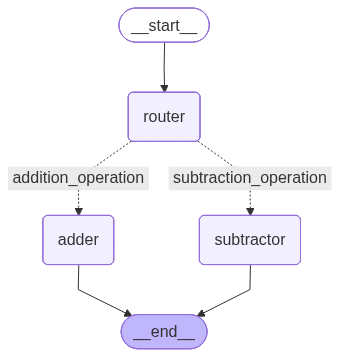

In [6]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [10]:
initial_state_1 = AgentState(number1=10, operation="-", number2=5, finalNumber=0)
print(app.invoke(initial_state_1))  # Should perform subtraction

{'number1': 10, 'operation': '-', 'number2': 5, 'finalNumber': 5}
